In [1]:
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df_links = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/links.csv")
df_nodes = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/nodes.csv", sep="\t")
df_topics = pd.read_csv("/content/drive/My Drive/ORF387_Project/heaberlin_dedeo_norm_network/topics.csv", sep="\t")
df_all_node_features = df_nodes.merge(df_topics, on="Page ID", how="left")

G = nx.from_pandas_edgelist(df_links, source="Source", target="Target", create_using=nx.MultiDiGraph)
G.add_nodes_from((n, dict(d)) for n, d in df_all_node_features.iterrows())

In [3]:
print(df_links)
print(df_nodes)
print(df_topics)

       Source  Target
0           0     117
1           0     491
2           0     603
3           0     773
4           0    1020
...       ...     ...
17230    1975    1038
17231    1975    1254
17232    1975    1381
17233    1975    1719
17234    1975    1765

[17235 rows x 2 columns]
      Page ID                              Name            Creation Date  \
0           0        In_popular_culture_content  2007-02-12 18:56:47 UTC   
1           1                Murder_of_articles  2013-05-14 04:15:31 UTC   
2           2          Note_that_is_unnecessary  2011-03-12 10:12:12 UTC   
3           3                       1.5_sources  2008-09-22 11:20:51 UTC   
4           4  100,000_feature-quality_articles  2006-09-14 15:06:24 UTC   
...       ...                               ...                      ...   
1971     1971                  Youth_protection  2006-10-21 21:55:59 UTC   
1972     1972                               Zap  2005-09-02 21:21:41 UTC   
1973     1973             

In [4]:
id_to_name = df_nodes.set_index("Page ID")["Name"].to_dict()
id_to_name[1010]

'Nationality_of_people_from_the_United_Kingdom'

In [5]:
# Eigenvector Centrality (PageRank with epsilon = 0.15), same as study
ec = nx.pagerank(G, alpha=0.85)
ec_vals = np.array(list(ec.values()))

In [6]:
# Compare to paper's EC Estimate
df_nodes["EC_ours"] = df_nodes["Page ID"].map(ec)
df_nodes["EC_error"] = abs(df_nodes["EC_ours"] - df_nodes["EC Estimate"])
print(df_nodes[["Name", "EC Estimate", "EC_ours", "EC_error"]].sort_values("EC Estimate", ascending=False).head(20))
print(f"\nMean absolute error: {df_nodes['EC_error'].mean():.6f}")
print(f"Correlation: {df_nodes[['EC Estimate','EC_ours']].corr().iloc[0,1]:.4f}")

                               Name  EC Estimate   EC_ours      EC_error
1020          Neutral_point_of_view     0.019026  0.019052  2.622924e-05
1683                  Verifiability     0.017736  0.017715  2.100499e-05
773    Identifying_reliable_sources     0.015340  0.015303  3.725923e-05
1719          What_Wikipedia_is_not     0.015039  0.015038  9.872467e-07
207   Biographies_of_living_persons     0.014059  0.014082  2.257665e-05
320                       Consensus     0.012339  0.012350  1.111818e-05
1224        Policies_and_guidelines     0.012242  0.012228  1.451741e-05
45                   Administrators     0.012134  0.012106  2.804421e-05
1053           No_original_research     0.011334  0.011342  8.197674e-06
281                  Citing_sources     0.010551  0.010545  6.104236e-06
131               Assume_good_faith     0.010276  0.010378  1.015117e-04
1086                     Notability     0.008675  0.008648  2.678089e-05
213                 Blocking_policy     0.008600  0

In [7]:
wcc = max(nx.weakly_connected_components(G), key=len)
scc = max(nx.strongly_connected_components(G), key=len)
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}, Density: {nx.density(G):.4f} (paper: 0.0044)")
print(f"Giant Weakly Connected Component: {len(wcc)/G.number_of_nodes():.2%}  (paper: 95%)")
print(f"Giant Strongly Connected Component: {len(scc)/G.number_of_nodes():.2%}")

Nodes: 1976, Edges: 17235, Density: 0.0044 (paper: 0.0044)
Giant Weakly Connected Component: 94.74%  (paper: 95%)
Giant Strongly Connected Component: 68.07%


In [8]:
# Table 1: Top 20 Core Norms
top20 = sorted(ec.items(), key=lambda x: x[1], reverse=True)[:20]
print("Top 20 by EC:\n")
for rank, (node, score) in enumerate(top20, 1):
    print(f"  {rank:2}. node={id_to_name[node]:<30s}  EC={score:.6f}")

Top 20 by EC:

   1. node=Neutral_point_of_view           EC=0.019052
   2. node=Verifiability                   EC=0.017715
   3. node=Identifying_reliable_sources    EC=0.015303
   4. node=What_Wikipedia_is_not           EC=0.015038
   5. node=Biographies_of_living_persons   EC=0.014082
   6. node=Consensus                       EC=0.012350
   7. node=Policies_and_guidelines         EC=0.012228
   8. node=Administrators                  EC=0.012106
   9. node=No_original_research            EC=0.011342
  10. node=Citing_sources                  EC=0.010545
  11. node=Assume_good_faith               EC=0.010378
  12. node=Blocking_policy                 EC=0.008652
  13. node=Notability                      EC=0.008648
  14. node=Dispute_resolution              EC=0.008015
  15. node=Redirect                        EC=0.007935
  16. node=Civility                        EC=0.007851
  17. node=Arbitration_Committee           EC=0.007676
  18. node=Vandalism                       EC=0.00

In [9]:
df_nodes["Age"] = (pd.Timestamp("2015-08-20", tz="UTC") - pd.to_datetime(df_nodes["Creation Date"], utc=True)).dt.days / 365

In [10]:
# TABLE B.1
print("TABLE B.1\n")
for col, paper_r in [("Fraction of total pageviews (July 2015)", 0.32), ("Number of Edits", 0.70), ("Number of Talk Page Edits", 0.63), ("Unique Editors", 0.72)]:
    r, p = pearsonr(df_nodes["EC_ours"].values, df_nodes[col].values)
    print(f"\t{col:<45} r={r:.2f}, p={p}, (paper: {paper_r})")

TABLE B.1

	Fraction of total pageviews (July 2015)       r=0.31, p=1.7010157639728544e-46, (paper: 0.32)
	Number of Edits                               r=0.70, p=1.0409573592643864e-292, (paper: 0.7)
	Number of Talk Page Edits                     r=0.63, p=9.996113196423217e-217, (paper: 0.63)
	Unique Editors                                r=0.72, p=3.72123367e-316, (paper: 0.72)


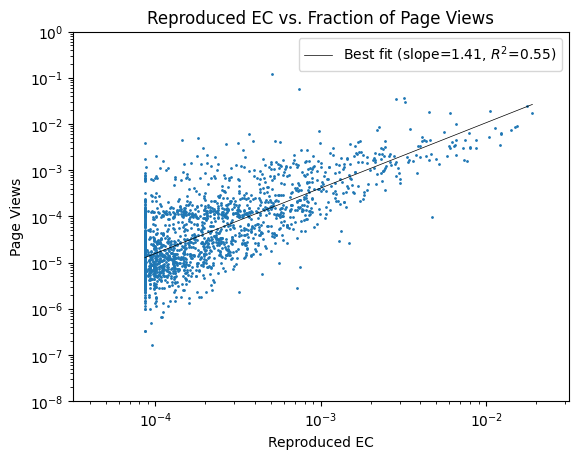

In [11]:
# FIGURE B.1
fig, ax = plt.subplots()
ax.scatter(df_nodes["EC_ours"], df_nodes["Fraction of total pageviews (July 2015)"], s=1)

cond = (df_nodes["EC_ours"] > 0) & (df_nodes["Fraction of total pageviews (July 2015)"] > 0)
log_x = np.log10(df_nodes.loc[cond, "EC_ours"]).values.reshape(-1, 1)
log_y = np.log10(df_nodes.loc[cond, "Fraction of total pageviews (July 2015)"]).values
model = LinearRegression().fit(log_x, log_y)
slope, intercept = model.coef_[0], model.intercept_
r_value = model.score(log_x, log_y)
x_fit = np.logspace(log_x.min(), log_x.max(), 200)
ax.plot(x_fit, 10 ** (intercept + slope * np.log10(x_fit)), color="black", linewidth=0.5,
        label=f"Best fit (slope={slope:.2f}, $R^2$={r_value:.2f})")

ax.legend()
ax.set_xlabel("Reproduced EC")
ax.set_xscale("log")
ax.set_ylabel("Page Views")
ax.set_yscale("log")
ax.set_ylim(10**-8, 10**0)
ax.set_xlim(10**-4.5, 10**-1.5)
ax.set_title("Reproduced EC vs. Fraction of Page Views")
plt.show()

In [12]:
# TABLE C.1
feats = ["Unique Editors", "Number of Talk Page Edits", "Page Size", "Age", "Number of Edits"]
X = StandardScaler().fit_transform(df_nodes[feats])
y = df_nodes["EC_ours"].values
m = LinearRegression().fit(X, y)
print(f"TABLE C.1  R²={m.score(X,y):.2f} (paper: 0.57)\n")
for idx, name in enumerate(feats):
    print(f"\t{name:<40} {m.coef_[idx] / 10**(-5):.3f} * 1e-5")
# These values are within the error of the original paper

TABLE C.1  R²=0.57 (paper: 0.57)

	Unique Editors                           95.270 * 1e-5
	Number of Talk Page Edits                46.234 * 1e-5
	Page Size                                2.823 * 1e-5
	Age                                      2.028 * 1e-5
	Number of Edits                          -30.327 * 1e-5


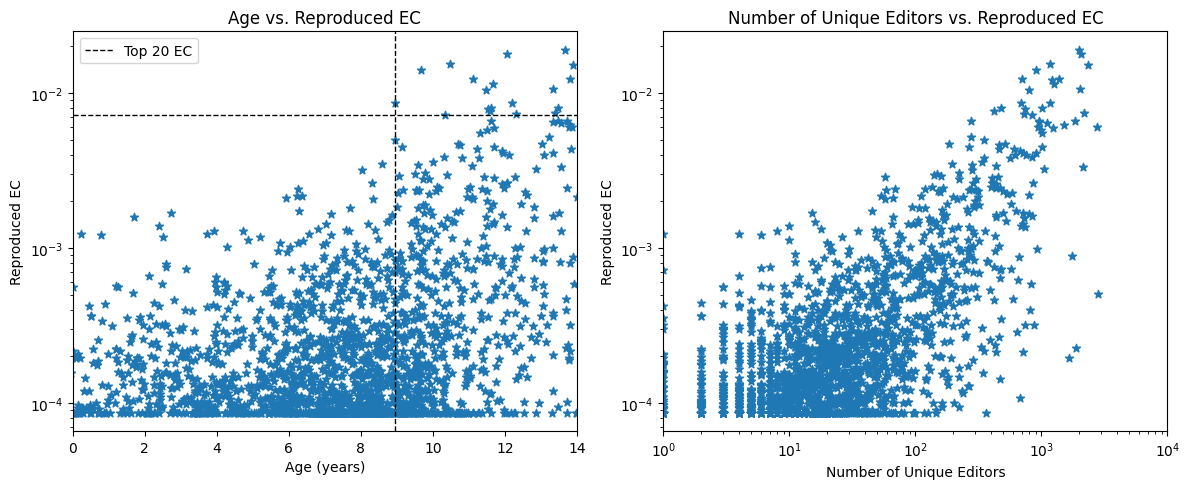

In [13]:
# FIGURE C.1: age and unique editors vs EC
ec_thresh = df_nodes["EC_ours"].nlargest(20).min()
age_thresh = df_nodes.nlargest(20, "EC_ours")["Age"].min()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(df_nodes["Age"], df_nodes["EC_ours"],marker="*")
ax1.axhline(ec_thresh, color="black", lw=1, linestyle="--", label="Top 20 EC")
ax1.axvline(age_thresh, color="black", lw=1, linestyle="--")

ax1.set_yscale("log")
ax1.set_xlim(0, 14)
ax1.set_xlabel("Age (years)")
ax1.set_ylabel("Reproduced EC")
ax1.set_title("Age vs. Reproduced EC")
ax1.legend()

ax2.scatter(df_nodes["Unique Editors"], df_nodes["EC_ours"], marker="*")
ax2.set_xlim(10**0, 10**4)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Number of Unique Editors")
ax2.set_ylabel("Reproduced EC")
ax2.set_title("Number of Unique Editors vs. Reproduced EC")

plt.tight_layout()
plt.show()

In [14]:
df_nodes["Type"].unique()

array(['Essay', 'Other', 'Humor', 'Basic', 'Proposal', 'Guideline',
       'Policy', 'Culture', 'Convention', 'Information'], dtype=object)

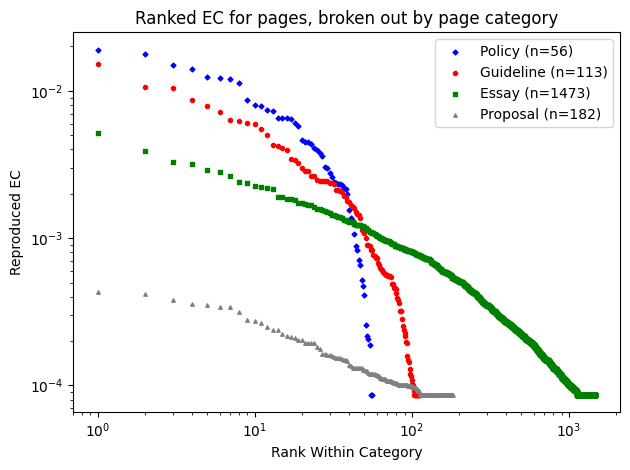

In [15]:
# Figure D.1: Ranked EC by category
df_d1 = df_nodes.copy()
df_d1["PlotType"] = df_d1["Type"].replace({"Humor": "Essay", "Basic": "Essay", "Culture": "Essay", "Convention": "Essay", "Information": "Essay"})
cat_styles = {
    "Policy":    ("blue",  "D", "Policy"),
    "Guideline": ("red",   "P", "Guideline"),
    "Essay":     ("green", "s", "Essay"),
    "Proposal":  ("gray",  "^", "Proposal"),
}
fig, ax = plt.subplots()
for content_type, (color, marker, label) in cat_styles.items():
    sub = df_d1[df_d1["PlotType"] == content_type].sort_values("EC_ours", ascending=False)
    ax.scatter(range(1, len(sub) + 1), sub["EC_ours"].values, s=6, c=color, marker=marker, label=f"{label} (n={len(sub)})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Rank Within Category")
ax.set_ylabel("Reproduced EC")
ax.set_title("Ranked EC for pages, broken out by page category")
ax.legend()
plt.tight_layout()
plt.show()

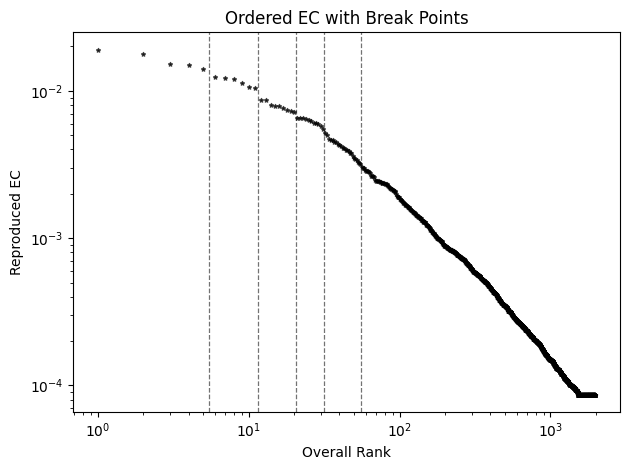

In [16]:
# Figure D.2: Overall sorted EC with break points
ec_arr = df_nodes.sort_values("EC_ours", ascending=False)["EC_ours"].values
gaps = -np.diff(ec_arr)
bp = []
for i in np.argsort(gaps)[::-1]:
    rk = i + 1.5
    if rk > 5 and all(abs(rk - b) > 5 for b in bp):
        bp.append(rk)
    if len(bp) == 5:
        break
fig, ax = plt.subplots()
ax.scatter(range(1, len(ec_arr) + 1), ec_arr, s=8, c="black", marker="*", alpha=0.7)
for b in bp:
    ax.axvline(x=b, color="black", ls="--", lw=0.9, alpha=0.55)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Overall Rank")
ax.set_ylabel("Reproduced EC")
ax.set_title("Ordered EC with Break Points")
plt.tight_layout()
plt.show()

In [17]:
def gini(vals):
    v = np.sort(np.asarray(vals, dtype=float))
    n = len(v)
    if n == 0 or v.sum() == 0:
        return 0.0
    return (2.0 * np.dot(np.arange(1, n + 1), v)) / (n * v.sum()) - (n + 1.0) / n
print(f"Gini: {gini(ec_vals):.4f}  (paper: ~0.68)")

Gini: 0.6845  (paper: ~0.68)


In [18]:
dt_series = pd.to_datetime(
    df_nodes.set_index("Page ID")["Creation Date"], utc=True)
dates = sorted(dt_series.unique())
gini_vals = []
date_vals = []
for cutoff in dates:
    aset  = set(dt_series[dt_series <= cutoff].index)
    sub_e = df_links[df_links["Source"].isin(aset) & df_links["Target"].isin(aset)]
    Gs    = nx.from_pandas_edgelist(sub_e, "Source", "Target", create_using=nx.MultiDiGraph)
    Gs.add_nodes_from(aset)

    ec_day = nx.pagerank(Gs, alpha=0.85)
    gini_vals.append(gini(list(ec_day.values())))
    date_vals.append(cutoff)
date_vals = pd.to_datetime(date_vals)

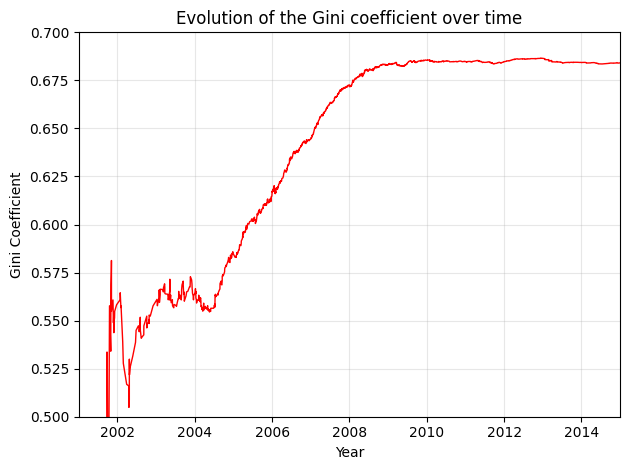

In [19]:
# Figure 2
fig, ax = plt.subplots()
ax.plot(date_vals, gini_vals, "r-", lw=1.0)
ax.set_xlabel("Year")
ax.set_ylabel("Gini Coefficient")
ax.set_title("Evolution of the Gini coefficient over time")
ax.grid(True, alpha=0.3)
ax.set_xlim(pd.Timestamp("2001-01-01", tz="UTC"), pd.Timestamp("2014-12-31", tz="UTC"))
ax.set_ylim(0.5, 0.7)
plt.tight_layout()
plt.show()

In [20]:
# Table F.2
df = df_nodes.copy()
df["EC"] = df["Page ID"].map(ec)
df = df[df["Louvain Community"] != -1]

cluster_sizes = (
    df.groupby("Louvain Community")
    .size()
    .sort_values(ascending=False)
    .head(9)
)
cluster_labels = {
    1: "Article Quality",
    2: "Collaboration",
    3: "Administrators",
    4: "Formatting Articles",
    5: "Content Policies",
    6: "Wiki-larping",
    7: "Page Templates",
    8: "Experts and Credentials",
    9: "Humor",
}
rows = []
for rank, (cid, _) in enumerate(cluster_sizes.items(), 1):
    top_pages = (
        df[df["Louvain Community"] == cid]
        .nlargest(7, "EC")["Name"]
        .str.replace("_", " ")
        .tolist()
    )
    rows.append({
        "Rank":    rank,
        "Cluster": cluster_labels[cid],
        "Top Pages by EC": " · ".join(top_pages),
    })
tableF2 = pd.DataFrame(rows).set_index("Rank")
pd.set_option("display.max_colwidth", 200)
print(tableF2.to_string())

                      Cluster                                                                                                                                                                 Top Pages by EC
Rank                                                                                                                                                                                                         
1             Article Quality            Neutral point of view · Verifiability · Identifying reliable sources · What Wikipedia is not · Biographies of living persons · No original research · Citing sources
2               Collaboration                                                   Consensus · Policies and guidelines · Assume good faith · Dispute resolution · Civility · Edit warring · Talk page guidelines
3              Administrators                                                          Administrators · Blocking policy · Arbitration Committee · Vandalism · User pages · Sock 

In [21]:
labels = {
    1: ("User-Content",          "Article Quality"),
    2: ("User-User",             "Collaboration"),
    3: ("User-Administration",   "Administrators"),
    4: ("User-Content",          "Formatting Articles"),
    5: ("User-Content",          "Content Policies"),
    6: ("User-User",             "Wiki-larping"),
    7: ("User-Content",          "Page Templates"),
    8: ("User-User/User-Content","Experts and Credentials"),
    9: ("User-User",             "Humor"),
}
rows = []
for rank, (cid, count) in enumerate(cluster_sizes.items(), 1):
    classification, topic = labels[cid]
    rows.append({
        "Rank":               rank,
        "Fraction of System": f"{count / cluster_sizes.sum():.1%}",
        "Classification":     classification,
        "Topic":              topic,
    })
table2 = pd.DataFrame(rows).set_index("Rank")
print(table2.to_string())

     Fraction of System          Classification                    Topic
Rank                                                                    
1                 24.9%            User-Content          Article Quality
2                 23.0%               User-User            Collaboration
3                 17.1%     User-Administration           Administrators
4                 14.8%            User-Content      Formatting Articles
5                 10.5%            User-Content         Content Policies
6                  5.5%               User-User             Wiki-larping
7                  2.0%            User-Content           Page Templates
8                  1.3%  User-User/User-Content  Experts and Credentials
9                  1.0%               User-User                    Humor


# BowTie Analysis


In [22]:
# Filter nodes by timestamp up to end of 2007
df_nodes_by_timestamp = pd.to_datetime(df_nodes.set_index("Page ID")["Creation Date"], utc=True)
cutoff_2007 = pd.Timestamp("2007-12-31", tz="UTC")
df_nodes_2007 = df_nodes_by_timestamp[df_nodes_by_timestamp <= cutoff_2007].index
# Filter edges by timestamp up to
mask = df_links["Source"].isin(df_nodes_2007) & df_links["Target"].isin(df_nodes_2007)
df_links_2007 = df_links[mask]

G_2007 = nx.from_pandas_edgelist(df_links_2007, source="Source", target="Target", create_using=nx.MultiDiGraph)
G_2007.add_nodes_from((n, dict(d)) for n, d in df_all_node_features[df_all_node_features["Page ID"].isin(df_nodes_2007)].iterrows())

In [23]:
def bowTieGrapher(G):
  lscc = set(max(nx.strongly_connected_components(G), key=len))
  rep = next(iter(lscc))
  fwd = nx.descendants(G, rep)
  bwd = nx.ancestors(G, rep)
  in_nodes = bwd - lscc
  out_nodes = fwd - lscc

  G2 = G.copy()
  G2.add_node("__SRC__")
  G2.add_node("__SNK__")
  for n in in_nodes:
      G2.add_edge("__SRC__", n)
  for n in out_nodes:
      G2.add_edge(n, "__SNK__")

  G_bypass = G2.copy()
  G_bypass.remove_nodes_from(lscc)

  in_reach_bypass  = nx.descendants(G_bypass, "__SRC__") - {"__SNK__"}
  out_reach_bypass = nx.ancestors(G_bypass,  "__SNK__") - {"__SRC__"}

  tubes       = (in_reach_bypass & out_reach_bypass) - out_nodes
  not_others  = lscc | in_nodes | out_nodes
  tendril_in  = in_reach_bypass  - not_others - tubes
  tendril_out = out_reach_bypass - not_others - tubes
  disconnected = set(G.nodes()) - not_others - tubes - tendril_in - tendril_out
  components = {
      "LSCC":        lscc,
      "IN":          in_nodes,
      "OUT":         out_nodes,
      "TUBE":        tubes,
      "TENDRIL_IN":  tendril_in,
      "TENDRIL_OUT": tendril_out,
      "DISCONNECTED":disconnected,
      }
  node_class = {n: cls for cls, nodes in components.items() for n in nodes}
  total = G.number_of_nodes()
  print(f"\n{'Component':<14} {'Count':>7}  {'Share':>7}")
  print("-" * 34)
  for name, nodes in components.items():
      n = len(nodes)
      print(f"{name:<14} {n:>7}  ({n/total:.2%})")
  print("-" * 34)
  print(f"{'TOTAL':<14} {total:>7}")
  bow_colors = {
      "LSCC":        "#8B0000",
      "IN":          "#1f77b4",
      "OUT":         "#17becf",
      "TUBE":        "#2ca02c",
      "TENDRIL_IN":  "#e377c2",
      "TENDRIL_OUT": "#bcbd22",
      "DISCONNECTED":"#6c3d99",
      }
  node_colors = np.array([bow_colors[node_class[n]] for n in G.nodes()])
  pos = nx.forceatlas2_layout(G, scaling_ratio=15, gravity=5)

  fig, ax = plt.subplots(figsize=(12, 12))
  nx.draw_networkx_edges(G, pos=pos, ax=ax, edge_color="#aaaaaa", alpha=0.12, width=0.4, arrows=False)
  nx.draw_networkx_nodes(G, pos=pos, ax=ax, node_size=30, node_color=node_colors, alpha=0.75, linewidths=0.2)
  handles = [
      ax.scatter([], [], c=color, s=40, label=f"{name} ({len(components[name])})")
      for name, color in bow_colors.items()
      ]
  ax.legend(handles=handles, loc="lower left", fontsize=9, framealpha=0.8)
  ax.set_title("Wikipedia Norm Network: Bow-Tie Decomposition")
  ax.axis("off")
  plt.show()


Component        Count    Share
----------------------------------
LSCC               652  (64.88%)
IN                 236  (23.48%)
OUT                 41  (4.08%)
TUBE                 6  (0.60%)
TENDRIL_IN           6  (0.60%)
TENDRIL_OUT          1  (0.10%)
DISCONNECTED        69  (6.87%)
----------------------------------
TOTAL             1005


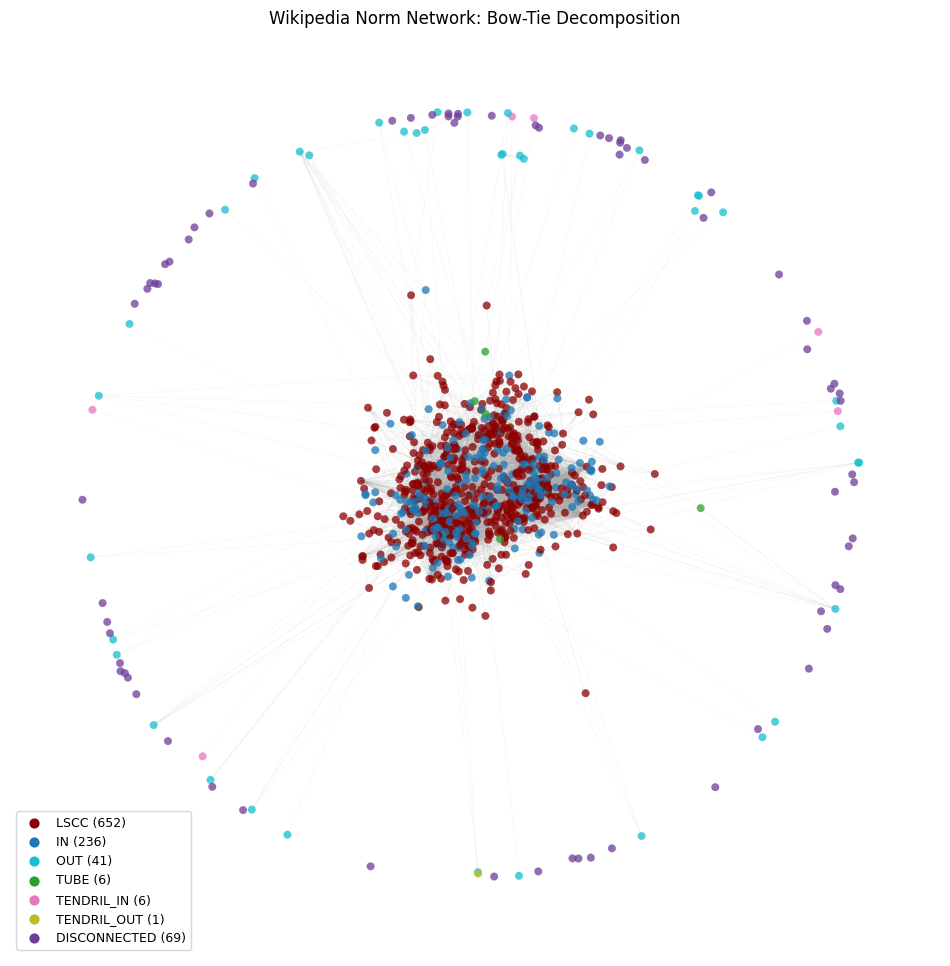

In [24]:
bowTieGrapher(G_2007)


Component        Count    Share
----------------------------------
LSCC              1345  (68.07%)
IN                 441  (22.32%)
OUT                 77  (3.90%)
TUBE                18  (0.91%)
TENDRIL_IN           8  (0.40%)
TENDRIL_OUT          1  (0.05%)
DISCONNECTED       104  (5.26%)
----------------------------------
TOTAL             1976


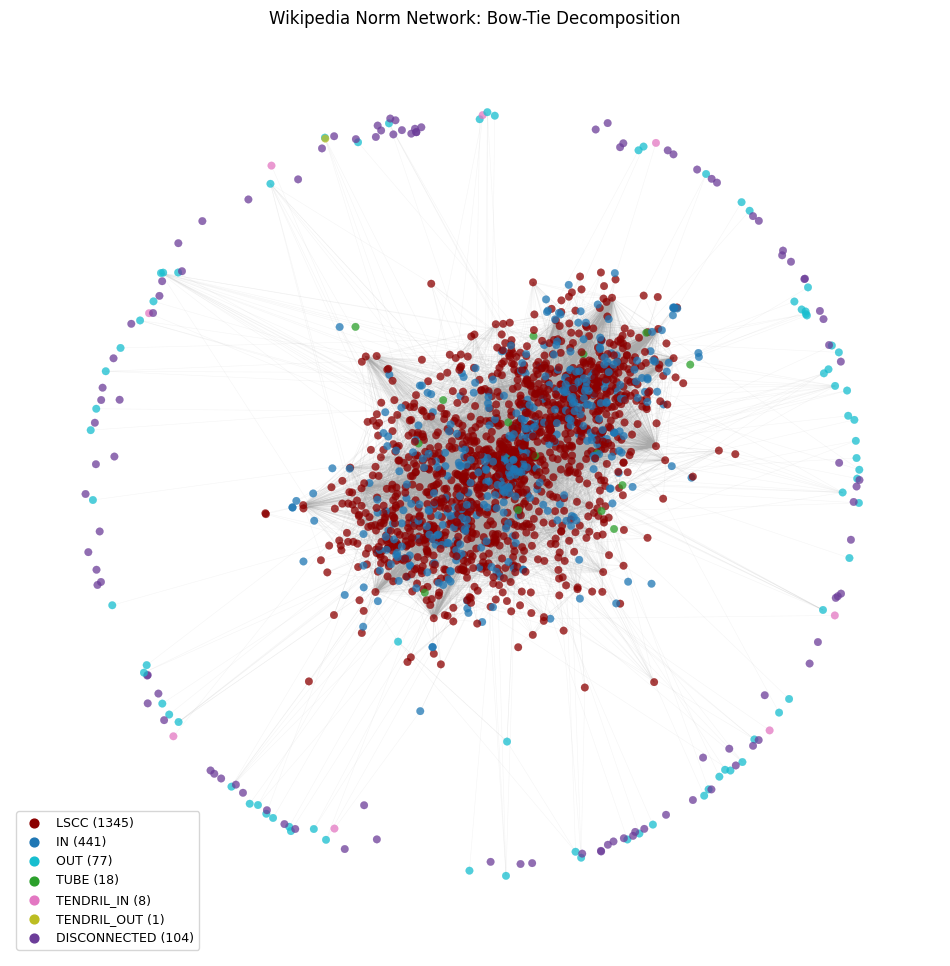

In [25]:
bowTieGrapher(G)